# AlexNet Baseline: MangoLeafBD Dataset
## Mango Leaf Disease & Pest Classification (Paper-Style Baseline)

**Author**: Md Imdadul Islam  
**Date**: November 2025  
**Model**: AlexNet (Custom Implementation)  
**Dataset**: MangoLeafBD

---

### Paper-Style Baseline Settings
This notebook follows the **MangoLeafXNet paper** baseline methodology:
- **Input Size**: 227×227 (matching paper)
- **Preprocessing**: Simple rescale (1/255) + standard augmentations
- **Optimizer**: SGD with momentum=0.9 (no Nesterov)
- **Training**: Fixed epochs, no early stopping
- **Callbacks**: Minimal (checkpoint + CSV logger only)

---

## 1. Setup & Configuration

### Import Required Libraries

In [25]:
# Core libraries
import os
import sys
import json
import time
import random
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, GlobalAveragePooling2D, Flatten,
    Conv2D, MaxPooling2D, BatchNormalization, Activation
)
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import SGD

# Model-specific import
# AlexNet: Custom implementation (not in keras.applications)

# Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

✅ All libraries imported successfully!
TensorFlow version: 2.15.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Set Random Seeds for Reproducibility

In [26]:
# Set seed for reproducibility
SEED = 42

def set_seed(seed_value=42):
    """Set seed for reproducibility across all libraries"""
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)

set_seed(SEED)
print(f"✅ Random seed set to {SEED} for reproducibility")

✅ Random seed set to 42 for reproducibility


### Configure Paths and Dataset

In [27]:
# ============================================
# PATH CONFIGURATION
# ============================================

from pathlib import Path

# 1) Identify dataset + model for this notebook
DATASET_NAME = 'MangoLeafBD'   # Dataset for this notebook
MODEL_NAME   = 'AlexNet'     # Model architecture name

# 2) Project root - MangoXPPNet_Research_Notebook workspace
WORKSPACE_DIR = Path('/Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook')

# 3) Datasets (via symbolic link in workspace)
DATASETS_BASE = WORKSPACE_DIR / 'datasets'
DATA_DIR  = DATASETS_BASE / DATASET_NAME / 'processed'
TRAIN_DIR = DATA_DIR / 'train'
VAL_DIR   = DATA_DIR / 'val'
TEST_DIR  = DATA_DIR / 'test'

# 4) Experiments and outputs save to THIS workspace
EXPERIMENTS_ROOT = WORKSPACE_DIR / DATASET_NAME / 'experiments'
OUTPUTS_ROOT     = WORKSPACE_DIR / DATASET_NAME / 'outputs'

# 5) Helper to create incrementing run directories
def get_next_run_dir(parent_dir, prefix='run_'):
    """Finds the next available run directory (run_1, run_2, ...)"""
    parent_dir = Path(parent_dir)
    parent_dir.mkdir(parents=True, exist_ok=True)
    existing = [d for d in parent_dir.iterdir()
                if d.is_dir() and d.name.startswith(prefix)]
    nums = [int(d.name[len(prefix):]) for d in existing
            if d.name[len(prefix):].isdigit()]
    next_num = max(nums) + 1 if nums else 1
    return parent_dir / f'{prefix}{next_num}'

# 6) Model-aware directory structure
EXPERIMENTS_BASE = EXPERIMENTS_ROOT / MODEL_NAME
OUTPUTS_BASE     = OUTPUTS_ROOT / MODEL_NAME

EXPERIMENT_DIR = get_next_run_dir(EXPERIMENTS_BASE)
OUTPUT_DIR     = get_next_run_dir(OUTPUTS_BASE)

EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Display configuration
print("="*60)
print("📁 PATH CONFIGURATION")
print("="*60)
print(f"Workspace      : {WORKSPACE_DIR}")
print(f"Dataset Name   : {DATASET_NAME}")
print(f"Model Name     : {MODEL_NAME}")
print(f"Data Directory : {DATA_DIR}")
print(f"Experiment Dir : {EXPERIMENT_DIR}")
print(f"Output Dir     : {OUTPUT_DIR}")
print("="*60)

# Verify paths exist
for name, path in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    if path.exists():
        print(f"✅ {name} directory exists")
    else:
        print(f"❌ {name} directory NOT FOUND: {path}")

📁 PATH CONFIGURATION
Workspace      : /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook
Dataset Name   : MangoLeafBD
Model Name     : AlexNet
Data Directory : /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/datasets/MangoLeafBD/processed
Experiment Dir : /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/AlexNet/run_3
Output Dir     : /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/outputs/AlexNet/run_3
✅ Train directory exists
✅ Val directory exists
✅ Test directory exists


### Paper-Style Hyperparameters

In [28]:
# ============================================
# PAPER-STYLE HYPERPARAMETERS
# ============================================
# These settings match the MangoLeafXNet paper baselines

IMG_SIZE = 227  # Match MangoLeafXNet paper

# Dataset-specific hyperparameters (from the paper)
if DATASET_NAME in ['MangoLeafBD', 'MangoLeafBD/']:
    EPOCHS = 100
    BATCH_SIZE = 12
    LEARNING_RATE = 0.001
elif DATASET_NAME in ['MangoPest', 'MangoPest/']:
    EPOCHS = 50
    BATCH_SIZE = 12
    LEARNING_RATE = 0.001
elif DATASET_NAME in ['MLDID', 'MLDID/']:
    EPOCHS = 100
    BATCH_SIZE = 16
    LEARNING_RATE = 0.0005
else:
    # Fallback
    EPOCHS = 100
    BATCH_SIZE = 12
    LEARNING_RATE = 0.001

DROPOUT_RATE = 0.3  # Modest dropout for baseline

print("="*60)
print("⚙️  PAPER-STYLE HYPERPARAMETERS")
print("="*60)
print(f"Input Size     : {IMG_SIZE}×{IMG_SIZE} (paper standard)")
print(f"Batch Size     : {BATCH_SIZE}")
print(f"Epochs         : {EPOCHS} (fixed, no early stopping)")
print(f"Learning Rate  : {LEARNING_RATE}")
print(f"Dropout Rate   : {DROPOUT_RATE}")
print(f"Optimizer      : SGD (momentum=0.9)")
print("="*60)

⚙️  PAPER-STYLE HYPERPARAMETERS
Input Size     : 227×227 (paper standard)
Batch Size     : 12
Epochs         : 100 (fixed, no early stopping)
Learning Rate  : 0.001
Dropout Rate   : 0.3
Optimizer      : SGD (momentum=0.9)


## 2. Data Loading & Preprocessing

### Simple Paper-Style Data Generators

In [29]:
# ============================================
# PAPER-STYLE DATA GENERATORS
# ============================================
# Simple rescale + standard augmentations (same for all models)

# Training: rescale + augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.8, 1.2),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & Test: rescale only (NO augmentation)
val_test_datagen = ImageDataGenerator(
    rescale=1.0/255.0
)

# Create generators
train_generator = train_datagen.flow_from_directory(
    str(TRAIN_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_directory(
    str(VAL_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

test_generator = val_test_datagen.flow_from_directory(
    str(TEST_DIR),
    target_size=(IMG_SIZE, IMG_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Get number of classes and class names
n_classes = len(train_generator.class_indices)
idx2name = [None] * n_classes
for name, idx in train_generator.class_indices.items():
    idx2name[idx] = name

print("\n" + "="*60)
print("📚 DATA GENERATORS CREATED (Paper-Style)")
print("="*60)
print(f"Preprocessing  : rescale=1/255 (same for all models)")
print(f"Augmentation   : rotation, shift, zoom, flip, brightness")
print(f"Number of Classes: {n_classes}")
print(f"Class Order: {idx2name}")
print(f"Training samples  : {train_generator.samples}")
print(f"Validation samples: {val_generator.samples}")
print(f"Test samples      : {test_generator.samples}")
print("="*60)

# Save classes.json
with open(EXPERIMENT_DIR / 'classes.json', 'w') as f:
    json.dump(idx2name, f, indent=2)

print(f"\n✅ Class order saved to: {EXPERIMENT_DIR / 'classes.json'}")

Found 3200 images belonging to 8 classes.
Found 400 images belonging to 8 classes.
Found 400 images belonging to 8 classes.

📚 DATA GENERATORS CREATED (Paper-Style)
Preprocessing  : rescale=1/255 (same for all models)
Augmentation   : rotation, shift, zoom, flip, brightness
Number of Classes: 8
Class Order: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Training samples  : 3200
Validation samples: 400
Test samples      : 400

✅ Class order saved to: /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/AlexNet/run_3/classes.json


## 3. Model Architecture

### Build AlexNet Baseline Model

In [30]:
# ============================================
# ALEXNET BASELINE MODEL (Custom Implementation)
# ============================================
# AlexNet is not in keras.applications, so we build it from scratch
# Added BatchNormalization for stable training

def build_alexnet(input_shape, num_classes, dropout_rate=0.3):
    """
    Build AlexNet architecture with BatchNormalization.
    """
    inputs = Input(shape=input_shape, name='input')
    
    # Conv Block 1
    x = Conv2D(96, (11, 11), strides=4, padding='valid', name='conv1')(inputs)
    x = BatchNormalization(name='bn1')(x)
    x = Activation('relu', name='relu1')(x)
    x = MaxPooling2D((3, 3), strides=2, name='pool1')(x)
    
    # Conv Block 2
    x = Conv2D(256, (5, 5), padding='same', name='conv2')(x)
    x = BatchNormalization(name='bn2')(x)
    x = Activation('relu', name='relu2')(x)
    x = MaxPooling2D((3, 3), strides=2, name='pool2')(x)
    
    # Conv Block 3
    x = Conv2D(384, (3, 3), padding='same', name='conv3')(x)
    x = BatchNormalization(name='bn3')(x)
    x = Activation('relu', name='relu3')(x)
    
    # Conv Block 4
    x = Conv2D(384, (3, 3), padding='same', name='conv4')(x)
    x = BatchNormalization(name='bn4')(x)
    x = Activation('relu', name='relu4')(x)
    
    # Conv Block 5
    x = Conv2D(256, (3, 3), padding='same', name='conv5')(x)
    x = BatchNormalization(name='bn5')(x)
    x = Activation('relu', name='relu5')(x)
    x = MaxPooling2D((3, 3), strides=2, name='pool5')(x)
    
    # Fully Connected Layers
    x = Flatten(name='flatten')(x)
    
    x = Dense(4096, name='fc1')(x)
    x = BatchNormalization(name='bn_fc1')(x)
    x = Activation('relu', name='relu_fc1')(x)
    x = Dropout(dropout_rate, name='dropout1')(x)
    
    x = Dense(4096, name='fc2')(x)
    x = BatchNormalization(name='bn_fc2')(x)
    x = Activation('relu', name='relu_fc2')(x)
    x = Dropout(dropout_rate, name='dropout2')(x)
    
    outputs = Dense(num_classes, activation='softmax', name='output')(x)
    
    return Model(inputs, outputs, name='AlexNet_baseline')


print("\n" + "="*60)
print(f"🏗️  BUILDING {MODEL_NAME} BASELINE MODEL")
print("="*60)

model = build_alexnet(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=n_classes,
    dropout_rate=DROPOUT_RATE
)

print(f"✅ AlexNet model built successfully!")
print(f"   • Input Shape: {IMG_SIZE}×{IMG_SIZE}×3")
print(f"   • Number of Classes: {n_classes}")
print(f"   • Architecture: Custom with BatchNormalization")
print(f"   • Training: From scratch (no pretrained weights)")

model.summary()


🏗️  BUILDING AlexNet BASELINE MODEL
✅ AlexNet model built successfully!
   • Input Shape: 227×227×3
   • Number of Classes: 8
   • Architecture: Custom with BatchNormalization
   • Training: From scratch (no pretrained weights)
Model: "AlexNet_baseline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (InputLayer)          [(None, 227, 227, 3)]     0         
                                                                 
 conv1 (Conv2D)              (None, 55, 55, 96)        34944     
                                                                 
 bn1 (BatchNormalization)    (None, 55, 55, 96)        384       
                                                                 
 relu1 (Activation)          (None, 55, 55, 96)        0         
                                                                 
 pool1 (MaxPooling2D)        (None, 27, 27, 96)        0         
                   

## 4. Model Training

### Compile and Train (Paper-Style)

In [31]:
# ============================================
# COMPILE MODEL (Paper-Style)
# ============================================
# SGD with momentum=0.9, no Nesterov (matching paper)

optimizer = SGD(learning_rate=LEARNING_RATE, momentum=0.9, nesterov=False)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled (Paper-style)")
print(f"   • Optimizer: SGD (momentum=0.9, no Nesterov)")
print(f"   • Learning Rate: {LEARNING_RATE} (fixed)")
print(f"   • Loss: Categorical Crossentropy")

✅ Model compiled (Paper-style)
   • Optimizer: SGD (momentum=0.9, no Nesterov)
   • Learning Rate: 0.001 (fixed)
   • Loss: Categorical Crossentropy


In [32]:
# ============================================
# MINIMAL CALLBACKS (Paper-Style)
# ============================================
# No EarlyStopping, no ReduceLROnPlateau
# Just checkpoint best model and log training

model_filename = f"{MODEL_NAME}_{DATASET_NAME}_best.h5"
model_path = EXPERIMENT_DIR / model_filename
csv_log_path = EXPERIMENT_DIR / 'training_log.csv'

callbacks = [
    ModelCheckpoint(
        filepath=str(model_path),
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    CSVLogger(
        filename=str(csv_log_path),
        append=False
    )
]

print("="*60)
print("🔧 MINIMAL CALLBACKS (Paper-Style)")
print("="*60)
print(f"ModelCheckpoint: Save best model to {model_filename}")
print(f"CSVLogger: Log to {csv_log_path.name}")
print("NO EarlyStopping (train for full {EPOCHS} epochs)")
print("NO ReduceLROnPlateau (fixed learning rate)")
print("="*60)

# Save model info
total_params = model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])

model_info = {
    'dataset': DATASET_NAME,
    'model_name': MODEL_NAME,
    'architecture': 'Custom AlexNet',
    'paper_style': True,
    'input_shape': [IMG_SIZE, IMG_SIZE, 3],
    'num_classes': n_classes,
    'total_params': int(total_params),
    'trainable_params': int(trainable_params),
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'optimizer': 'SGD (momentum=0.9)',
    'model_path': str(model_path)
}

with open(EXPERIMENT_DIR / 'model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

print(f"\n✅ Model info saved to: {EXPERIMENT_DIR / 'model_info.json'}")

🔧 MINIMAL CALLBACKS (Paper-Style)
ModelCheckpoint: Save best model to AlexNet_MangoLeafBD_best.h5
CSVLogger: Log to training_log.csv
NO EarlyStopping (train for full {EPOCHS} epochs)
NO ReduceLROnPlateau (fixed learning rate)

✅ Model info saved to: /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/AlexNet/run_3/model_info.json


In [33]:
# ============================================
# TRAINING (Paper-Style: Fixed Epochs)
# ============================================

print("\n" + "="*80)
print("🚀 STARTING TRAINING (Paper-Style Baseline)")
print("="*80)
print(f"Model: {MODEL_NAME}")
print(f"Dataset: {DATASET_NAME}")
print(f"Epochs: {EPOCHS} (fixed, no early stopping)")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Learning Rate: {LEARNING_RATE} (fixed, no decay)")
print("="*80 + "\n")

start_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

end_time = time.time()
training_time = end_time - start_time

print("\n" + "="*80)
print("✅ TRAINING COMPLETED")
print("="*80)
print(f"Total training time: {training_time/60:.2f} minutes")
print(f"Best model saved to: {model_path}")
print("="*80)

# Save training history
history_dict = {k: [float(x) for x in v] for k, v in history.history.items()}
with open(EXPERIMENT_DIR / 'history.json', 'w') as f:
    json.dump(history_dict, f, indent=2)

print(f"\n✅ Training history saved to: {EXPERIMENT_DIR / 'history.json'}")


🚀 STARTING TRAINING (Paper-Style Baseline)
Model: AlexNet
Dataset: MangoLeafBD
Epochs: 100 (fixed, no early stopping)
Batch Size: 12
Learning Rate: 0.001 (fixed, no decay)

Epoch 1/100


2025-11-27 05:28:34.719048: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node SGD/AssignVariableOp.


267/267 [==============================] - ETA: 0s - loss: 1.8280 - accuracy: 0.4703
Epoch 1: val_accuracy improved from -inf to 0.18500, saving model to /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/AlexNet/run_3/AlexNet_MangoLeafBD_best.h5
267/267 [==============================] - 22s 73ms/step - loss: 1.8280 - accuracy: 0.4703 - val_loss: 5.3841 - val_accuracy: 0.1850
Epoch 2/100
267/267 [==============================] - ETA: 0s - loss: 0.9568 - accuracy: 0.6997
Epoch 2: val_accuracy improved from 0.18500 to 0.62000, saving model to /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/AlexNet/run_3/AlexNet_MangoLeafBD_best.h5
267/267 [==============================] - 18s 67ms/step - loss: 0.9568 - accuracy: 0.6997 - val_loss: 1.1970 - val_accuracy: 0.6200
Epoch 3/100
267/267 [==============================] - ETA: 0s - loss: 0.8042 - accuracy: 0.7541
Epoch 3: val_accuracy improved from 0.62000 

## 5. Model Evaluation

### Load Best Model and Generate Predictions

In [34]:
# ============================================
# MODEL EVALUATION
# ============================================

print("="*60)
print("📥 LOADING BEST MODEL FOR EVALUATION")
print("="*60)
print(f"Model path: {model_path}")

best_model = load_model(str(model_path))
print("✅ Best model loaded successfully!")

# Make predictions
print("\n🔮 Making predictions on test set...")
y_pred_probs = best_model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

# Calculate metrics
overall_accuracy = accuracy_score(y_true, y_pred)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro'
)
weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

# Classification report
report = classification_report(
    y_true, y_pred,
    target_names=idx2name,
    digits=4
)

print("\n" + "="*80)
print("📊 EVALUATION RESULTS")
print("="*80)
print(f"Overall Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Macro F1-Score  : {macro_f1:.4f}")
print("="*80)
print("\n" + report)

# Save classification report
with open(OUTPUT_DIR / 'classification_report.txt', 'w') as f:
    f.write(f"{MODEL_NAME} on {DATASET_NAME} - Classification Report\n")
    f.write("="*80 + "\n\n")
    f.write(report)

# Save metrics CSV
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=range(n_classes)
)
metrics_df = pd.DataFrame({
    'Class': idx2name,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
metrics_df.to_csv(OUTPUT_DIR / 'per_class_metrics.csv', index=False)

# Save evaluation summary
summary = f"""{'='*80}
{MODEL_NAME} on {DATASET_NAME} - Evaluation Summary (Paper-Style Baseline)
{'='*80}

Model: {MODEL_NAME}
Dataset: {DATASET_NAME}
Test Accuracy: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)
Macro Avg - P: {macro_precision:.4f}, R: {macro_recall:.4f}, F1: {macro_f1:.4f}
Weighted Avg - P: {weighted_precision:.4f}, R: {weighted_recall:.4f}, F1: {weighted_f1:.4f}

Training Settings:
- Input Size: {IMG_SIZE}×{IMG_SIZE}
- Epochs: {EPOCHS} (fixed)
- Batch Size: {BATCH_SIZE}
- Learning Rate: {LEARNING_RATE}
- Optimizer: SGD (momentum=0.9)
{'='*80}
"""

with open(OUTPUT_DIR / 'evaluation_summary.txt', 'w') as f:
    f.write(summary)

print(f"\n✅ Results saved to: {OUTPUT_DIR}")

📥 LOADING BEST MODEL FOR EVALUATION
Model path: /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/experiments/AlexNet/run_3/AlexNet_MangoLeafBD_best.h5


✅ Best model loaded successfully!

🔮 Making predictions on test set...
34/34 [==============================] - 1s 17ms/step

📊 EVALUATION RESULTS
Overall Accuracy: 0.9950 (99.50%)
Macro Precision : 0.9950
Macro Recall    : 0.9950
Macro F1-Score  : 0.9950

                  precision    recall  f1-score   support

     Anthracnose     1.0000    1.0000    1.0000        50
Bacterial Canker     1.0000    0.9800    0.9899        50
  Cutting Weevil     1.0000    1.0000    1.0000        50
        Die Back     1.0000    1.0000    1.0000        50
      Gall Midge     0.9800    0.9800    0.9800        50
         Healthy     1.0000    1.0000    1.0000        50
  Powdery Mildew     0.9804    1.0000    0.9901        50
     Sooty Mould     1.0000    1.0000    1.0000        50

        accuracy                         0.9950       400
       macro avg     0.9950    0.9950    0.9950       400
    weighted avg     0.9950    0.9950    0.9950       400


✅ Results saved to: /Users/invictus/Desktop

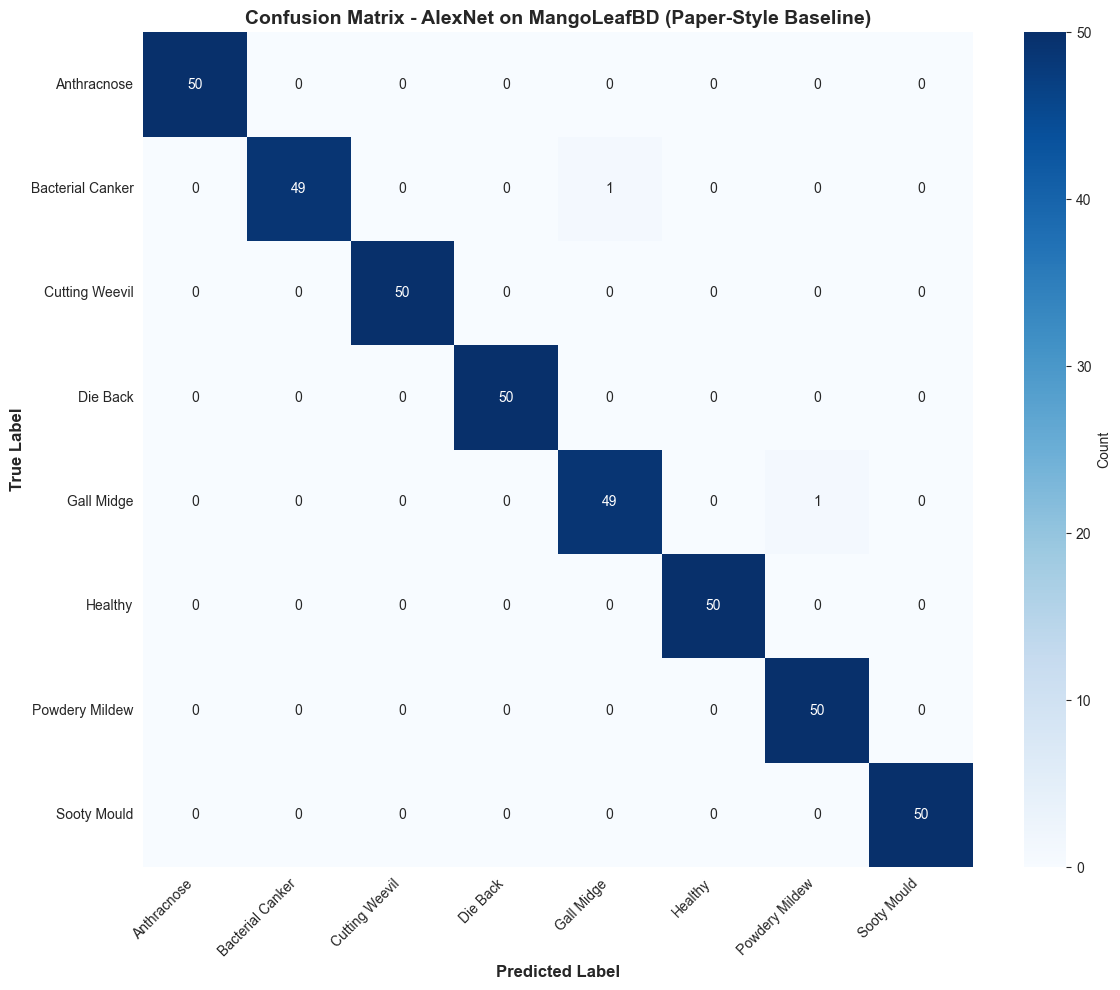

✅ Confusion matrix saved to: /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/outputs/AlexNet/run_3/confusion_matrix.png


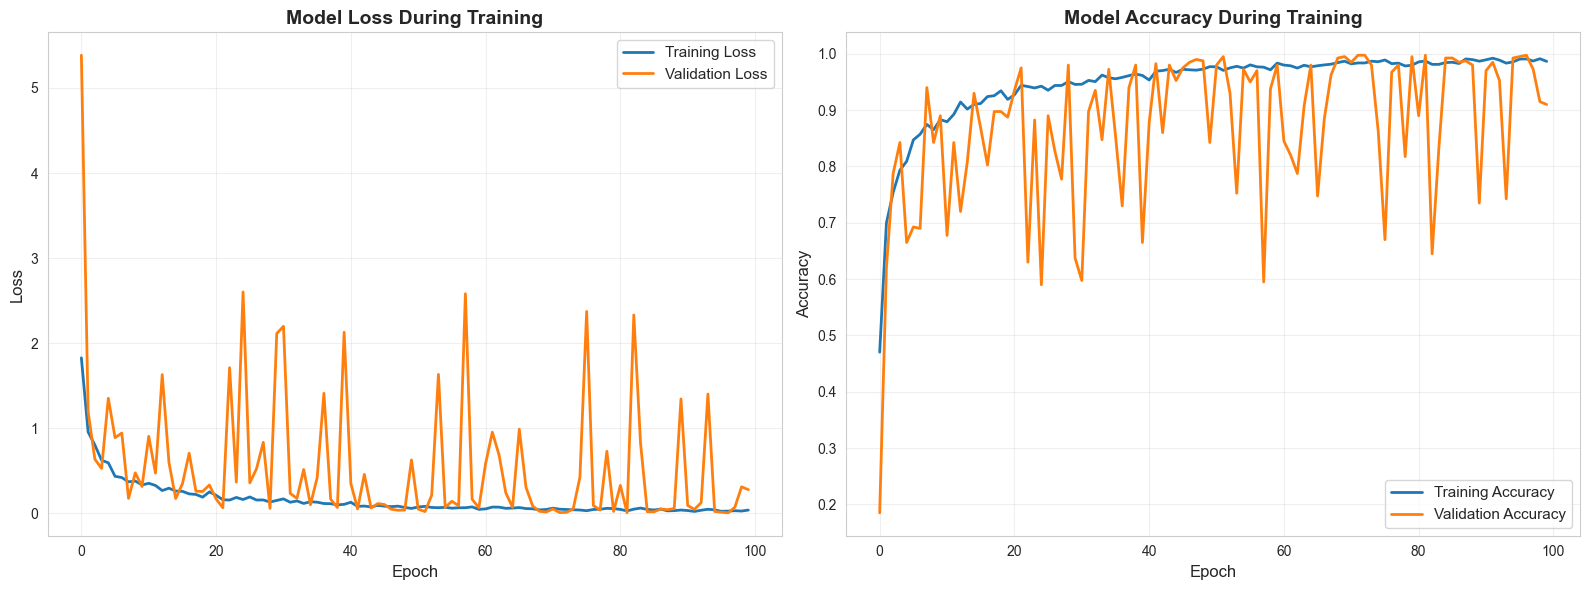

✅ Training history plot saved to: /Users/invictus/Desktop/Thesis project/MangoXPPNet_Research_Notebook/MangoLeafBD/outputs/AlexNet/run_3/training_history.png


In [35]:
# ============================================
# VISUALIZATIONS
# ============================================

# 1) Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=idx2name,
            yticklabels=idx2name,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title(f'Confusion Matrix - {MODEL_NAME} on {DATASET_NAME} (Paper-Style Baseline)',
         fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Confusion matrix saved to: {OUTPUT_DIR / 'confusion_matrix.png'}")

# 2) Training History
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss plot
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss During Training', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy During Training', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Training history plot saved to: {OUTPUT_DIR / 'training_history.png'}")